In [ ]:
# ▶ Warnings 제거
import warnings
warnings.filterwarnings('ignore')

# ▶ Google drive mount or 폴더 클릭 후 구글드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

# ▶ 경로 설정 (※ Colab을 활성화시켰다면 보통 Colab Notebooks 폴더가 자동 생성)
import os
os.chdir("/content/drive/MyDrive/AX 수업")
os.getcwd()

import pandas as pd
df = pd.read_csv('top_insta_influencers_data.csv')
df.head()

Mounted at /content/drive


,rank,channel_info,influence_score,posts,followers,avg_likes,60_day_eng_rate,new_post_avg_like,total_likes,country
0,1,cristiano,92,3.3k,475.8m,8.7m,1.39%,6.5m,29.0b,Spain
1,2,kyliejenner,91,6.9k,366.2m,8.3m,1.62%,5.9m,57.4b,United States
2,3,leomessi,90,0.89k,357.3m,6.8m,1.24%,4.4m,6.0b,NaN
3,4,selenagomez,93,1.8k,342.7m,6.2m,0.97%,3.3m,11.5b,United States
4,5,therock,91,6.8k,334.1m,1.9m,0.20%,665.3k,12.5b,United States


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   rank               200 non-null    int64 
 1   channel_info       200 non-null    object
 2   influence_score    200 non-null    int64 
 3   posts              200 non-null    object
 4   followers          200 non-null    object
 5   avg_likes          200 non-null    object
 6   60_day_eng_rate    200 non-null    object
 7   new_post_avg_like  200 non-null    object
 8   total_likes        200 non-null    object
 9   country            138 non-null    object
dtypes: int64(2), object(8)
memory usage: 15.8+ KB


In [ ]:
df.describe()

,rank,influence_score
count,200.000000,200.000000
mean,100.500000,81.820000
std,57.879185,8.878159
min,1.000000,22.000000
25%,50.750000,80.000000
50%,100.500000,84.000000
75%,150.250000,86.000000
max,200.000000,93.000000


In [ ]:
df.shape

(200, 10)

In [ ]:
print(df.dtypes)

rank                  int64
channel_info         object
influence_score       int64
posts                object
followers            object
avg_likes            object
60_day_eng_rate      object
new_post_avg_like    object
total_likes          object
country              object
dtype: object


In [ ]:
print(df.isnull().sum())

rank                  0
channel_info          0
influence_score       0
posts                 0
followers             0
avg_likes             0
60_day_eng_rate       0
new_post_avg_like     0
total_likes           0
country              62
dtype: int64


In [ ]:
print("✅ 데이터 Shape")
print(df.shape)

print("\\n✅ 데이터 타입")
print(df.dtypes)

print("\\n✅ 결측치 개수")
print(df.isnull().sum())

✅ 데이터 Shape
(200, 10)
\n✅ 데이터 타입
rank                  int64
channel_info         object
influence_score       int64
posts                object
followers            object
avg_likes            object
60_day_eng_rate      object
new_post_avg_like    object
total_likes          object
country              object
dtype: object
\n✅ 결측치 개수
rank                  0
channel_info          0
influence_score       0
posts                 0
followers             0
avg_likes             0
60_day_eng_rate       0
new_post_avg_like     0
total_likes           0
country              62
dtype: int64


In [ ]:
df['followers']

,followers
0,475.8m
1,366.2m
2,357.3m
3,342.7m
4,334.1m
...,...
195,33.2m
196,33.2m
197,33.2m
198,33.0m


In [ ]:
df['country'] = df['country'].fillna('None')
df['country']

,country
0,Spain
1,United States
2,None
3,United States
4,United States
...,...
195,United States
196,France
197,Brazil
198,United States


In [ ]:
print(df.isnull().sum())

rank                 0
channel_info         0
influence_score      0
posts                0
followers            0
avg_likes            0
60_day_eng_rate      0
new_post_avg_like    0
total_likes          0
country              0
dtype: int64


In [13]:
import pandas as pd

def convert_to_number(value):
    """
    문자열 데이터를 수치형(float)으로 변환하는 함수입니다.
    - k, m, b 단위를 숫자로 환산합니다.
    - % 기호를 제거합니다.
    - 결측치나 잘못된 데이터는 0으로 처리합니다.
    """
    # 데이터가 비어있거나(NaN) 이미 숫자인 경우 처리
    if pd.isna(value):
        return 0.0
    if isinstance(value, (int, float)):
        return float(value)

    # 1. 소문자로 변경하고 양 끝 공백 제거
    val = str(value).lower().strip()

    # 2. 단위 기호 처리 (k=천, m=백만, b=십억)
    multiplier = 1.0
    if 'k' in val:
        multiplier = 1_000
        val = val.replace('k', '')
    elif 'm' in val:
        multiplier = 1_000_000
        val = val.replace('m', '')
    elif 'b' in val:
        multiplier = 1_000_000_000
        val = val.replace('b', '')

    # 3. % 기호 제거 (참여율 데이터용)
    if '%' in val:
        val = val.replace('%', '')

    # 4. 최종 숫자 변환
    try:
        # 콤마 제거 후 실수형으로 변환하고 단위를 곱함
        return float(val.replace(',', '')) * multiplier
    except ValueError:
        # 숫자로 바꿀 수 없는 문자열(예: 'unknown')은 0으로 처리
        return 0.0

# --- 실전 적용 및 테스트 코드 ---

# 파일 읽기
df = pd.read_csv('top_insta_influencers_data.csv')

# 변환이 필요한 컬럼 목록
target_cols = ['posts', 'followers', 'avg_likes', '60_day_eng_rate', 'new_post_avg_like', 'total_likes']

# 함수 적용
for col in target_cols:
    df[col] = df[col].apply(convert_to_number)

# 정수형으로 보고 싶다면 마지막에 astype(int)를 쓸 수 있으나,
# 참여율(%) 데이터는 소수점이 중요하므로 float 상태 유지를 권장합니다.

print("--- 변환 후 데이터 상위 5행 ---")
print(df[target_cols].head())

print("\n--- 데이터 타입 확인 ---")
print(df.dtypes)

--- 변환 후 데이터 상위 5행 ---
    posts    followers  avg_likes  60_day_eng_rate  new_post_avg_like  \
0  3300.0  475800000.0  8700000.0             1.39          6500000.0   
1  6900.0  366200000.0  8300000.0             1.62          5900000.0   
2   890.0  357300000.0  6800000.0             1.24          4400000.0   
3  1800.0  342700000.0  6200000.0             0.97          3300000.0   
4  6800.0  334100000.0  1900000.0             0.20           665300.0   

    total_likes  
0  2.900000e+10  
1  5.740000e+10  
2  6.000000e+09  
3  1.150000e+10  
4  1.250000e+10  

--- 데이터 타입 확인 ---
rank                   int64
channel_info          object
influence_score        int64
posts                float64
followers            float64
avg_likes            float64
60_day_eng_rate      float64
new_post_avg_like    float64
total_likes          float64
country               object
dtype: object


In [14]:
df.head()

,rank,channel_info,influence_score,posts,followers,avg_likes,60_day_eng_rate,new_post_avg_like,total_likes,country
0,1,cristiano,92,3300.0,475800000.0,8700000.0,1.39,6500000.0,2.900000e+10,Spain
1,2,kyliejenner,91,6900.0,366200000.0,8300000.0,1.62,5900000.0,5.740000e+10,United States
2,3,leomessi,90,890.0,357300000.0,6800000.0,1.24,4400000.0,6.000000e+09,NaN
3,4,selenagomez,93,1800.0,342700000.0,6200000.0,0.97,3300000.0,1.150000e+10,United States
4,5,therock,91,6800.0,334100000.0,1900000.0,0.20,665300.0,1.250000e+10,United States


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rank               200 non-null    int64  
 1   channel_info       200 non-null    object 
 2   influence_score    200 non-null    int64  
 3   posts              200 non-null    float64
 4   followers          200 non-null    float64
 5   avg_likes          200 non-null    float64
 6   60_day_eng_rate    199 non-null    float64
 7   new_post_avg_like  200 non-null    float64
 8   total_likes        200 non-null    float64
 9   country            138 non-null    object 
dtypes: float64(6), int64(2), object(2)
memory usage: 15.8+ KB


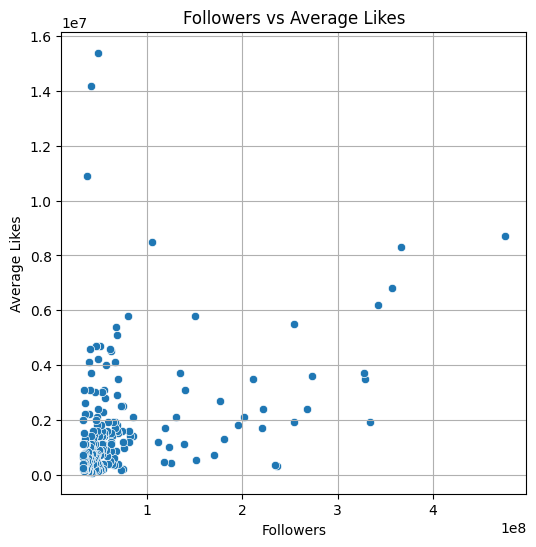

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 6))
sns.scatterplot(data=df, x='followers', y='avg_likes')

plt.title("Followers vs Average Likes")
plt.xlabel("Followers")
plt.ylabel("Average Likes")
plt.grid(True)
plt.show()

In [17]:
corr_followers_likes = df[['followers', 'avg_likes']].corr().iloc[0, 1]
print(round(corr_followers_likes, 3))

0.349


In [28]:
followers_75 = df['followers'].quantile(0.75)
likes_25 = df['avg_likes'].quantile(0.25)

print("팔로워 상위 25% 기준:", followers_75)
print("평균 좋아요 하위 25% 기준:", likes_25)

팔로워 상위 25% 기준: 68900000.0
평균 좋아요 하위 25% 기준: 504400.0


In [29]:
low_engagement_accounts = df[
    (df['followers'] >= followers_75) &
    (df['avg_likes'] <= likes_25)
]

low_engagement_accounts[
    ['rank', 'channel_info', 'followers', 'avg_likes', 'influence_score', 'country']
]

,rank,channel_info,followers,avg_likes,influence_score,country
11,12,natgeo,237000000.0,302200.0,91,United States
12,13,nike,234100000.0,329000.0,90,United States
27,28,theellenshow,125100000.0,420500.0,87,United States
30,31,chrisbrownofficial,118500000.0,463200.0,86,United States
40,41,snoopdogg,75300000.0,203700.0,86,NaN
44,45,victoriassecret,73200000.0,147000.0,88,United States
47,48,nba,70100000.0,370800.0,87,United States


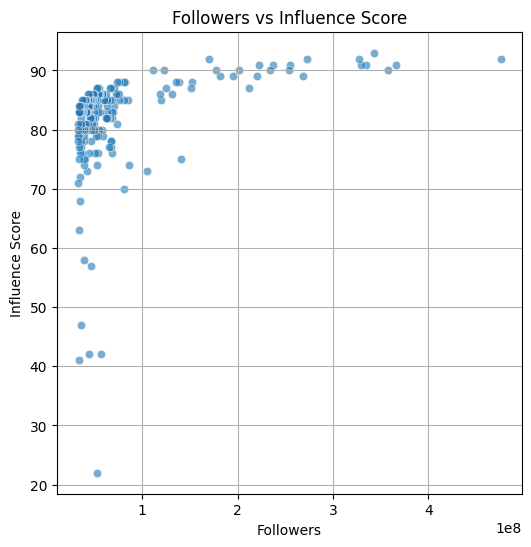

In [30]:
plt.figure(figsize=(6, 6))
sns.scatterplot(data=df, x='followers', y='influence_score', alpha=0.6)

plt.title("Followers vs Influence Score")
plt.xlabel("Followers")
plt.ylabel("Influence Score")
plt.grid(True)
plt.show()

In [31]:
corr_followers_score = df[['followers', 'influence_score']].corr().iloc[0, 1]
print(f"상관계수: {corr_followers_score:.3f}")

상관계수: 0.368


In [32]:
followers_75 = df['followers'].quantile(0.75)
influence_score_75 = df['influence_score'].quantile(0.75)

print("팔로워 상위 25% 기준:", followers_75)
print("영향력점수 상위 25% 기준:", influence_score_75)

high_engagement_accounts = df[
    (df['followers'] >= followers_75) &
    (df['influence_score'] <= influence_score_75)
]

high_engagement_accounts[
    ['rank', 'channel_info', 'followers', 'avg_likes', 'influence_score', 'country']
]

팔로워 상위 25% 기준: 68900000.0
영향력점수 상위 25% 기준: 86.0


,rank,channel_info,followers,avg_likes,influence_score,country
23,24,iamcardib,140500000.0,3100000.0,75,United States
26,27,kingjames,130900000.0,2100000.0,86,NaN
29,30,champagnepapi,119600000.0,1700000.0,85,Netherlands
30,31,chrisbrownofficial,118500000.0,463200.0,86,United States
32,33,billieeilish,105200000.0,8500000.0,73,NaN
33,34,dualipa,85900000.0,2100000.0,74,United Kingdom
34,35,gal_gadot,85600000.0,1400000.0,85,United States
37,38,priyankachopra,81100000.0,1600000.0,85,United States
38,39,lalalalisa_m,80900000.0,5800000.0,70,NaN
40,41,snoopdogg,75300000.0,203700.0,86,NaN


In [36]:
df['engagement_rate'] = df['avg_likes'] / df['followers']

In [35]:
engagement_rate = avg_likes / followers

NameError: name 'avg_likes' is not defined

In [37]:
top_engaged = df.sort_values(by='engagement_rate', ascending=False).head(10)

top_engaged[
    ['rank', 'channel_info', 'followers', 'avg_likes', 'engagement_rate', 'influence_score', 'country']
]

,rank,channel_info,followers,avg_likes,engagement_rate,influence_score,country
140,141,j.m,41900000.0,14200000.0,0.338902,83,NaN
102,103,thv,49300000.0,15400000.0,0.312373,83,NaN
167,168,rkive,37000000.0,10900000.0,0.294595,83,NaN
147,148,jenniferaniston,40700000.0,4600000.0,0.113022,85,NaN
155,156,mahi7781,39100000.0,4100000.0,0.104859,58,NaN
118,119,zayn,46500000.0,4700000.0,0.101075,82,United States
114,115,harrystyles,46900000.0,4700000.0,0.100213,57,United States
97,98,adele,50700000.0,4700000.0,0.092702,84,United States
186,187,blakelively,34600000.0,3100000.0,0.089595,80,United States
138,139,badbunnypr,42100000.0,3700000.0,0.087886,83,NaN


In [39]:
# 3. 새로운 참여율 지표 컬럼 추가 (평균 좋아요 수 / 팔로워 수 * 100)
# 주의: 팔로워가 0명일 경우 에러(ZeroDivisionError)가 날 수 있으므로, 0을 pd.NA로 바꿔 계산합니다.
df['new_eng_rate(%)'] = (df['avg_likes'] / df['followers'].replace(0, pd.NA)) * 100

# 4. 상위 25% (75th percentile) 기준값 찾기
top_25_threshold = df['new_eng_rate(%)'].quantile(0.75)

# 5. 상위 25% 이상인 데이터만 필터링하고, 참여율이 높은 순서대로 내림차순 정렬
top_25_df = df[df['new_eng_rate(%)'] >= top_25_threshold].sort_values(by='new_eng_rate(%)', ascending=False)

# 결과 출력 (필요한 컬럼만 깔끔하게 선택)
result_cols = ['channel_info', 'followers', 'avg_likes', 'new_eng_rate(%)']

print(f"✅ 상위 25% 커트라인 참여율: {top_25_threshold:.2f}%\n")
print("🏆 [상위 25% 인플루언서 리스트 Top 10]")
print(top_25_df[result_cols].head(10))

✅ 상위 25% 커트라인 참여율: 3.02%

🏆 [상위 25% 인플루언서 리스트 Top 10]
        channel_info   followers   avg_likes  new_eng_rate(%)
140              j.m  41900000.0  14200000.0        33.890215
102              thv  49300000.0  15400000.0        31.237323
167            rkive  37000000.0  10900000.0        29.459459
147  jenniferaniston  40700000.0   4600000.0        11.302211
155         mahi7781  39100000.0   4100000.0        10.485934
118             zayn  46500000.0   4700000.0        10.107527
114      harrystyles  46900000.0   4700000.0        10.021322
97             adele  50700000.0   4700000.0         9.270217
186      blakelively  34600000.0   3100000.0         8.959538
138       badbunnypr  42100000.0   3700000.0         8.788599


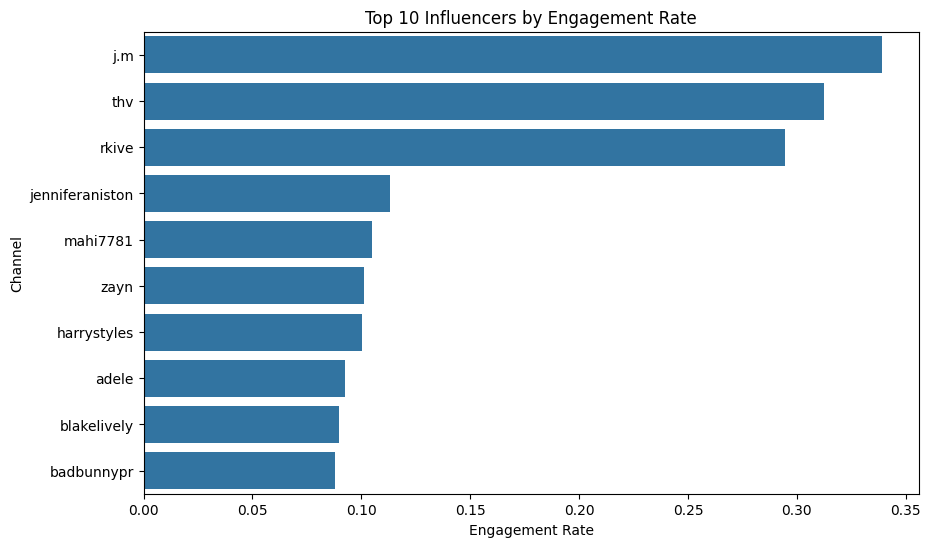

In [40]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_engaged,
    x='engagement_rate',
    y='channel_info'
)

plt.title("Top 10 Influencers by Engagement Rate")
plt.xlabel("Engagement Rate")
plt.ylabel("Channel")
plt.show()

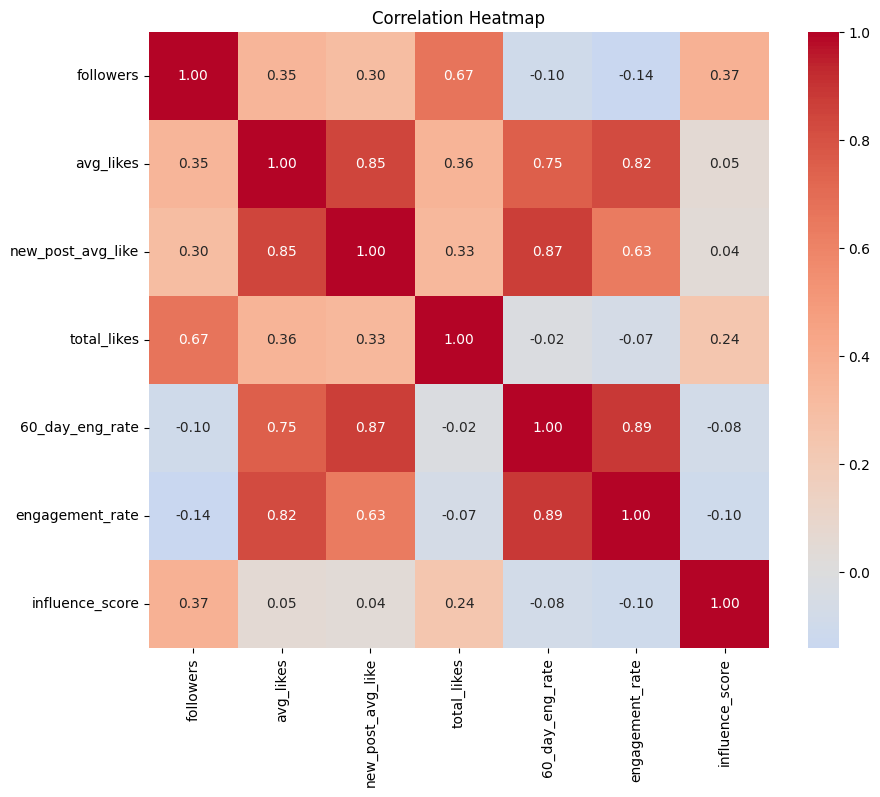

In [42]:
numeric_cols = [
    'followers',
    'avg_likes',
    'new_post_avg_like',
    'total_likes',
    '60_day_eng_rate',
    'engagement_rate',
    'influence_score'
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

In [44]:
import numpy as np

def minmax(series):
    return (series - series.min()) / (series.max() - series.min()) * 100

# 팔로워 수는 값 차이가 매우 크므로 로그 변환 후 점수화
df['followers_log'] = np.log1p(df['followers'])

df['followers_score_0_100'] = minmax(df['followers_log'])
df['engagement_score_0_100'] = minmax(df['engagement_rate'])
df['recent_eng_score_0_100'] = minmax(df['60_day_eng_rate'].fillna(0))
df['influence_score_0_100'] = minmax(df['influence_score'])

df['balanced_influencer_score'] = (
    0.35 * df['influence_score_0_100'] +
    0.25 * df['followers_score_0_100'] +
    0.25 * df['engagement_score_0_100'] +
    0.15 * df['recent_eng_score_0_100']
)

# 결과 확인
print("✅ 종합 영향력 점수 산출 완료")
print(df[['channel_info', 'balanced_influencer_score']].sort_values(by='balanced_influencer_score', ascending=False).head(10))

✅ 종합 영향력 점수 산출 완료
      channel_info  balanced_influencer_score
140            j.m                  72.359177
102            thv                  71.568580
0        cristiano                  61.556034
1      kyliejenner                  59.070755
3      selenagomez                  58.728884
2         leomessi                  57.862937
6     arianagrande                  57.444628
5    kimkardashian                  56.763814
4          therock                  56.149550
7          beyonce                  55.621913
